In [2]:
import dask
dask.config.set({'dataframe.query-planning': False}) 

import spatialdata
import sopa
import sopa.io
import sopa.segmentation
from pathlib import Path
import warnings


/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [ ]:
#azeaez

In [3]:
#CELLPOSE BIEN
'''
import dask
dask.config.set({'dataframe.query-planning': False}) 

import spatialdata
import sopa
import sopa.io
import sopa.segmentation
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

sopa.settings.parallelization_backend = None

#Toy
#sdata = sopa.io.toy_dataset(genes=500)

#Cropped
sdata = spatialdata.read_zarr("/home/lilian/CRCL/xenium_training/sopa_test_crop2.zarr")

#OG
#xenium_dir = Path("/home/lilian/Raw_Xenium/output_XETG00373_0059858_colon_IM_02_20250811_171708_ADK")
#sdata = sopa.io.xenium(xenium_dir)


print("1. Génération des patchs...")
sopa.make_image_patches(sdata, patch_width=2000, patch_overlap=150)

print("2. Inférence Cellpose (Flux tendu sur GPU)...")
sopa.segmentation.cellpose(
    sdata,
    channels=[0],            
    diameter=35.0,           
    pretrained_model="cyto3",
    gpu=True,                
    key_added="cellpose_boundaries"
)


output_zarr = Path("/home/lilian/CRCL/xenium_training/CRC_CP.zarr")
sdata.write(output_zarr, overwrite=True)

print(f"\n✓ Inférence terminée !")
print(f"Cellules détectées (Prior) : {len(sdata.shapes['cellpose_boundaries'])}")
'''

'\nimport dask\ndask.config.set({\'dataframe.query-planning\': False}) \n\nimport spatialdata\nimport sopa\nimport sopa.io\nimport sopa.segmentation\nfrom pathlib import Path\nimport warnings\n\nwarnings.filterwarnings("ignore")\n\nsopa.settings.parallelization_backend = None\n\n#Toy\n#sdata = sopa.io.toy_dataset(genes=500)\n\n#Cropped\nsdata = spatialdata.read_zarr("/home/lilian/CRCL/xenium_training/sopa_test_crop2.zarr")\n\n#OG\n#xenium_dir = Path("/home/lilian/Raw_Xenium/output_XETG00373_0059858_colon_IM_02_20250811_171708_ADK")\n#sdata = sopa.io.xenium(xenium_dir)\n\n\nprint("1. Génération des patchs...")\nsopa.make_image_patches(sdata, patch_width=2000, patch_overlap=150)\n\nprint("2. Inférence Cellpose (Flux tendu sur GPU)...")\nsopa.segmentation.cellpose(\n    sdata,\n    channels=[0],            \n    diameter=35.0,           \n    pretrained_model="cyto3",\n    gpu=True,                \n    key_added="cellpose_boundaries"\n)\n\n\noutput_zarr = Path("/home/lilian/CRCL/xenium_t

### Proseg - Cellpose Prior

In [18]:

xenium_dir = Path("/home/lilian/Raw_Xenium/output_XETG00373_0059858_colon_IM_02_20250811_171708_ADK")
sdata = sopa.io.xenium(xenium_dir)



In [13]:
sdata = spatialdata.read_zarr("/home/lilian/CRCL/xenium_training/CRC_Proseg.zarr")


version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/zarr/creation.py:610:

In [19]:
# Proseg
import sopa
import sopa.segmentation


print("1. patches")
sopa.make_transcript_patches(
    sdata,
    patch_width=None, 
    prior_shapes_key="auto")

print("2. Proseg")
sopa.segmentation.proseg(
    sdata, 
    key_added="proseg_boundaries")


print("Register")
output_zarr = Path("/home/lilian/CRCL/xenium_training/ADK/CRC_Proseg_ADK.zarr")
sdata.write(output_zarr, overwrite=True)


print(f"{len(sdata.shapes['proseg_boundaries'])}")

1. patches
[########################################] | 100% Completed | 22m 1ss


[INFO] (sopa.patches.transcripts) Added 1 patch(es) to sdata['transcripts_patches']
[INFO] (sopa.segmentation.methods._proseg) Running proseg with command: `proseg transcripts.csv -x x -y y -z z --gene-column feature_name --cell-id-column sopa_prior --cell-id-unassigned 0 --exclude-spatialdata-transcripts  --fov-column fov_name --qv-column qv --min-qv 20.0 --compartment-column overlaps_nucleus --compartment-nuclear 1`


2. Proseg
Using 16 threads
Finished reading input
Read dataset:
229948732 transcripts
   666652 cells
      480 genes
      235 fovs


Killed


CalledProcessError: Command 'proseg transcripts.csv -x x -y y -z z --gene-column feature_name --cell-id-column sopa_prior --cell-id-unassigned 0 --exclude-spatialdata-transcripts  --fov-column fov_name --qv-column qv --min-qv 20.0 --compartment-column overlaps_nucleus --compartment-nuclear 1' returned non-zero exit status 137.

### Aggrégation

In [ ]:
# Cellule 4 : Agrégation
import sopa


print("1. Agrégation")
sopa.aggregate(
    sdata, 
    aggregate_channels=True,
    shapes_key="proseg_boundaries",  
    key_added="adata_proseg" 
)

# Récupération de l'objet AnnData classique (scverse)
adata = sdata.tables["adata_proseg"]

print(f"{adata.n_obs} cellules, {adata.n_vars} gènes.")

print(adata)

output_zarr = Path("/home/lilian/CRCL/xenium_training/ADK/CRC_Proseg_ag_ADK.zarr")
sdata.write(output_zarr, overwrite=True)



1. Agrégation


[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 417605 cells


[########################################] | 100% Completed | 42.92 s


[INFO] (sopa.aggregation.channels) Aggregating channels intensity over 417605 cells with mode='average'


[########################################] | 100% Completed | 540.70 s


[INFO] (sopa.aggregation.aggregation) Filtering 9414 cells due to mean channel intensity < 181.94
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `proseg_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/sopa/aggregation/aggregation.py:202: ImplicitModificationWarning: Setting element `.obsm['intensities']` of view, initializing view as actual.
  self.table.obsm[SopaKeys.INTENSITIES_OBSM] = pd.DataFrame(
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `proseg_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


408191 cellules, 480 gènes.
AnnData object with n_obs × n_vars = 408191 × 480
    obs: 'region', 'slide', 'cell_id', 'area'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'intensities', 'spatial'


In [ ]:
xenium_dir = Path("/home/lilian/Raw_Xenium/output-XETG00373_0059858_colon_IM_01_20250811_171708_polype_HG")
sdata = sopa.io.xenium(xenium_dir)

In [ ]:
# Proseg
import sopa
import sopa.segmentation


print("1. patches")
sopa.make_transcript_patches(
    sdata,
    patch_width=None, 
    prior_shapes_key="auto")

print("2. Proseg")
sopa.segmentation.proseg(
    sdata, 
    key_added="proseg_boundaries")


print("Register")
output_zarr = Path("/home/lilian/CRCL/xenium_training/Polype/CRC_Proseg_P_HG.zarr")
sdata.write(output_zarr, overwrite=True)


print(f"{len(sdata.shapes['proseg_boundaries'])}")

In [ ]:
# Cellule 4 : Agrégation
import sopa


print("1. Agrégation")
sopa.aggregate(
    sdata, 
    aggregate_channels=True,
    shapes_key="proseg_boundaries",  
    key_added="adata_proseg" 
)

# Récupération de l'objet AnnData classique (scverse)
adata = sdata.tables["adata_proseg"]

print(f"{adata.n_obs} cellules, {adata.n_vars} gènes.")

print(adata)

output_zarr = Path("/home/lilian/CRCL/xenium_training/Polype/CRC_Proseg_ag_P_HG.zarr")
sdata.write(output_zarr, overwrite=True)

In [ ]:
xenium_dir = Path("/home/lilian/Raw_Xenium/output-output-XETG00373__0059861__colon-IM-04__20250811__171708_polype_BG")
sdata = sopa.io.xenium(xenium_dir)

In [ ]:
# Proseg
import sopa
import sopa.segmentation


print("1. patches")
sopa.make_transcript_patches(
    sdata,
    patch_width=None, 
    prior_shapes_key="auto")

print("2. Proseg")
sopa.segmentation.proseg(
    sdata, 
    key_added="proseg_boundaries")


print("Register")
output_zarr = Path("/home/lilian/CRCL/xenium_training/Polype/CRC_Proseg_P_BG.zarr")
sdata.write(output_zarr, overwrite=True)


print(f"{len(sdata.shapes['proseg_boundaries'])}")

In [ ]:
# Cellule 4 : Agrégation
import sopa


print("1. Agrégation")
sopa.aggregate(
    sdata, 
    aggregate_channels=True,
    shapes_key="proseg_boundaries",  
    key_added="adata_proseg" 
)

# Récupération de l'objet AnnData classique (scverse)
adata = sdata.tables["adata_proseg"]

print(f"{adata.n_obs} cellules, {adata.n_vars} gènes.")

print(adata)

output_zarr = Path("/home/lilian/CRCL/xenium_training/Polype/CRC_Proseg_ag_P_BG.zarr")
sdata.write(output_zarr, overwrite=True)



### Filtrage

In [14]:
import numpy as np
from scipy import sparse

print("--- Calcul QC Manuel (Méthode Robuste) ---")

# 1. Extraction de la matrice X
X = adata_clean.X

# 2. Calcul des métriques via algèbre matricielle simple
if sparse.issparse(X):
    # Somme sur l'axe 1 (colonnes) pour avoir le total par cellule
    total_counts = np.ravel(X.sum(axis=1))
    # Somme des valeurs > 0 pour avoir le nombre de gènes détectés
    n_genes = np.ravel((X > 0).sum(axis=1))
else:
    # Cas array dense (numpy classique)
    total_counts = np.ravel(X.sum(axis=1))
    n_genes = np.ravel(np.count_nonzero(X, axis=1))

# 3. Injection dans les métadonnées (obs)
adata_clean.obs['total_counts'] = total_counts
adata_clean.obs['n_genes_by_counts'] = n_genes

print(f"✓ SUCCÈS : Métriques calculées manuellement.")
print(f"   - Moyenne transcrits/cellule : {np.mean(total_counts):.1f}")
print(f"   - Moyenne gènes/cellule      : {np.mean(n_genes):.1f}")

# On remet l'objet dans la variable principale
adata = adata_clean

# --- SUITE DU FILTRAGE MAD (Qui fonctionnera maintenant) ---
print("\nApplication du filtre MAD...")
def is_outlier(adata, metric, nmads):
    M = adata.obs[metric]
    median = M.median()
    mad = np.median(np.abs(M - median))
    if mad == 0: return np.zeros(len(M), dtype=bool)
    return (M < median - nmads * mad) | (M > median + nmads * mad)

adata.obs["outlier"] = (
    is_outlier(adata, "total_counts", 5) | 
    is_outlier(adata, "n_genes_by_counts", 5)
)

adata = adata[~adata.obs.outlier].copy()
print(f"✓ Filtrage terminé. Reste : {adata.n_obs} cellules.")

--- Calcul QC Manuel (Méthode Robuste) ---
✓ SUCCÈS : Métriques calculées manuellement.
   - Moyenne transcrits/cellule : 145.8
   - Moyenne gènes/cellule      : 35.4

Application du filtre MAD...
✓ Filtrage terminé. Reste : 374942 cellules.


In [9]:
import scanpy as sc
import numpy as np

adata_raw = adata.copy()

if adata.is_view:
    print("Consolidation de l'objet AnnData (View -> Copy)...")
    adata = adata.copy()

print(f"Type actuel de l'index des gènes : {adata.var_names.dtype}")
print(f"Exemple d'index : {adata.var_names[:5].tolist()}")

# Scénario A : Les vrais noms de gènes sont cachés dans une colonne (ex: 'gene_symbols')
# C'est fréquent avec Xenium/SOPA qui met l'ID en index et le nom en colonne.
possible_name_cols = ['gene_symbols', 'Name', 'Symbol', 'gene', 'feature_name']
found_col = None

for col in possible_name_cols:
    if col in adata.var.columns:
        found_col = col
        break

if found_col:
    print(f"-> Vrais noms trouvés dans la colonne '{found_col}'. On les passe en index.")
    adata.var.index = adata.var[found_col].astype(str)
else:
    # Scénario B : Pas de colonne de nom, ou index purement numérique
    # On vérifie si l'index ressemble à des nombres
    if adata.var_names.str.isnumeric().any():
        print("-> ATTENTION : Index numériques détectés. Renommage sécurisé.")
        # On préfixe avec "g_" pour forcer l'interprétation en texte
        adata.var_names = [f"g_{i}_{name}" for i, name in enumerate(adata.var_names)]

# 3. Sécurisation finale
adata.var_names_make_unique()

sc.pp.calculate_qc_metrics(adata, var_type="genes", inplace=True)

adata_raw = adata.copy()

# Fonction MAD
def is_outlier(adata, metric, nmads):
    M = adata.obs[metric]
    median = M.median()
    mad = np.median(np.abs(M - median))
    return (M < median - nmads * mad) | (M > median + nmads * mad)

# Filtrage MAD
adata.obs["outlier"] = (
    is_outlier(adata, "total_counts", 5) | 
    is_outlier(adata, "n_genes_by_counts", 5)
)

print(f"Avant: {adata.n_obs} cellules | Outliers: {adata.obs.outlier.sum()}")

adata = adata[~adata.obs.outlier].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(f"Après: {adata_raw.n_obs} cellules, {adata_raw.n_vars} gènes")
print(f"Après: {adata.n_obs} cellules, {adata.n_vars} gènes")


Type actuel de l'index des gènes : object
Exemple d'index : ['ADGRE1', 'ADGRG6', 'ADH1B', 'ADORA2A', 'ADRA2A']


IndexError: Positions outside range of features.

Avec toydata 1gene ~1transcrit, pas de surexpression

### Viz

KeyError: "Could not find keys ['n_genes_by_counts'] in columns of `adata.obs` or in adata.var_names."

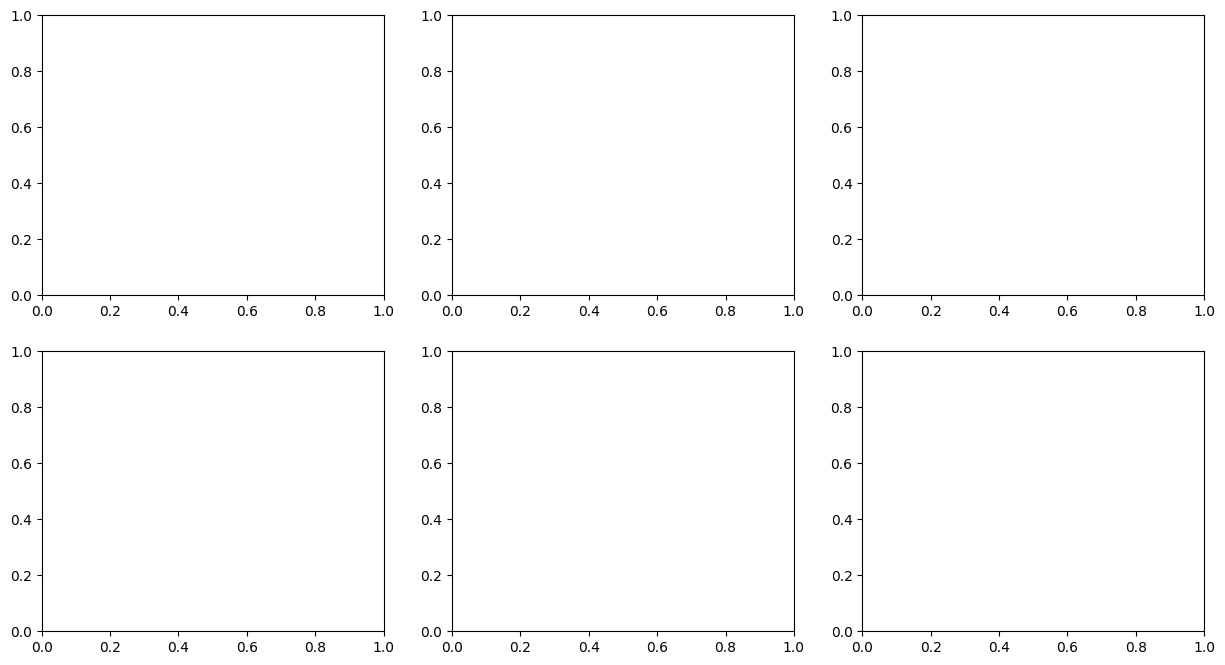

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sc.pl.violin(adata_raw, 'n_genes_by_counts', jitter=0.4, ax=axes[0,0], show=False)
axes[0,0].set_title("Avant: n_genes")
sc.pl.violin(adata_raw, 'total_counts', jitter=0.4, ax=axes[0,1], show=False)
axes[0,1].set_title("Avant: total_counts")
sc.pl.scatter(adata_raw, 'total_counts', 'n_genes_by_counts', ax=axes[0,2], show=False)
axes[0,2].set_title(f"Avant: {adata_raw.n_obs} cellules")

sc.pl.violin(adata, 'n_genes_by_counts', jitter=0.4, ax=axes[1,0], show=False)
axes[1,0].set_title("Après: n_genes")
sc.pl.violin(adata, 'total_counts', jitter=0.4, ax=axes[1,1], show=False)
axes[1,1].set_title("Après: total_counts")
sc.pl.scatter(adata, 'total_counts', 'n_genes_by_counts', ax=axes[1,2], show=False)
axes[1,2].set_title(f"Après: {adata.n_obs} cellules")

plt.tight_layout()
plt.savefig("qc_comparison.png", dpi=300)
plt.show()

print(f"Cellules supprimées: {adata_raw.n_obs - adata.n_obs} ({(adata_raw.n_obs - adata.n_obs)/adata_raw.n_obs*100:.1f}%)")
print(f"Gènes supprimés: {adata_raw.n_vars - adata.n_vars}")
print(f"\nMédiane transcrits/cell: {adata.obs['total_counts'].median():.0f}")
print(f"Médiane gènes/cell: {adata.obs['n_genes_by_counts'].median():.0f}")


### Novae

In [ ]:
### Novae
import novae
import scanpy as sc
import numpy as np

print("1. neighbors.")
novae.spatial_neighbors(adata, radius=50, technology="xenium")

print("2. normalisation")
novae.utils.prepare_adatas(adata)

print("3. model")
model = novae.Novae.from_pretrained("MICS-Lab/novae-human-0")

print("4. Compute")
model.compute_representations(adata, zero_shot=True)

print("5. domains")
model.assign_domains(adata)


### Metriqeues

print("6. Fide")
fide = novae.monitor.fide_score(adata, obs_key="novae_domain")
print(f"-> Score FIDE (Continuité Spatiale) : {fide:.3f}")

print("7. Viz")
novae.plot.domains(
    adata, 
    obs_key="novae_domain", 
    cell_size=15,
    fast=True
)

try:
    model.plot_domains_hierarchy(max_level=10, leaf_font_size=10)
except Exception as e:
    print(f"Info: Dendrogramme non généré ({e})")

print("Sauvegarde sopa_crc_novae_annotated.h5ad")
adata.write_h5ad("sopa_crc_novae_annotated.h5ad")

1. Construction du Graphe Spatial (Pruning actif)...


AssertionError: Running `novae.spatial_neighbors` with `technology` but `adata.obsm['spatial']` already exists.

## Data Checking

In [8]:
import spatialdata
from pathlib import Path

# 1. Chargement (Si pas déjà fait)
xenium_dir = Path("/home/lilian/Raw_Xenium/output_XETG00373_0059858_colon_IM_02_20250811_171708_ADK")
sdata = sopa.io.xenium(xenium_dir)

print(f"=== STRUCTURE GLOBALE ===\n{sdata}")

print("\n=== 1. IMAGES (Pyramides Raster) ===")
for key in sdata.images:
    img_obj = sdata.images[key]
    
    # Vérification : Est-ce une pyramide (DataTree) ou une image simple (Xarray) ?
    # Les DataTree n'ont pas de .shape, mais ils ont des clés (scale0, scale1...)
    if hasattr(img_obj, 'keys') and 'scale0' in img_obj.keys():
        print(f"- {key} [Format Pyramidal OME-Zarr] :")
        # On itère sur les résolutions disponibles
        for scale in img_obj.keys():
            # On descend dans l'arbre : Echelle -> Image
            arr = img_obj[scale]['image'] 
            print(f"  > {scale} : {arr.shape} pixels (Lazy Dask)")
    else:
        # Cas rare : Image simple (ex: après un crop non-pyramidal)
        print(f"- {key} [Image Simple] : {img_obj.shape}")

print("\n=== 2. POINTS (Transcrits) ===")
for key in sdata.points:
    pts = sdata.points[key]
    # Pour un Dask DataFrame, len() peut être lent car il doit compter les partitions.
    # On utilise map_partitions pour une estimation rapide si c'est très lourd, 
    # mais pour le diagnostic, len() est acceptable.
    print(f"- {key} : {len(pts)} molécules (Dask DataFrame)")

print("\n=== 3. SHAPES (Polygones) ===")
for key in sdata.shapes:
    sh = sdata.shapes[key]
    print(f"- {key} : {len(sh)} géométries")
    # Aperçu des métadonnées géométriques
    print(f"  Type : {sh.geometry.geom_type.unique()}")

print("\n=== 4. TABLE (AnnData) ===")
if sdata.table is not None:
    adata = sdata.table
    print(f"- Matrice : {adata.n_obs} cellules x {adata.n_vars} gènes")
    print(f"- Liaison spatiale : region='{adata.uns['spatialdata_attrs']['region']}'")
    # Vérification des clés importantes pour la suite (Novae/STAMapper)
    if 'spatial' in adata.obsm:
        print("  ✓ Coordonnées centroïdes présentes (obsm['spatial'])")
    if 'novae_domain' in adata.obs:
        print("  ✓ Annotation Novae présente")
else:
    print("- Pas de table AnnData associée (Lancer l'agrégation si nécessaire)")

=== STRUCTURE GLOBALE ===
SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 47869, 54084), (4, 23934, 27042), (4, 11967, 13521), (4, 5983, 6760), (4, 2991, 3380)
└── Points
      └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points)

=== 1. IMAGES (Pyramides Raster) ===
- morphology_focus [Format Pyramidal OME-Zarr] :
  > scale0 : (4, 47869, 54084) pixels (Lazy Dask)
  > scale1 : (4, 23934, 27042) pixels (Lazy Dask)
  > scale2 : (4, 11967, 13521) pixels (Lazy Dask)
  > scale3 : (4, 5983, 6760) pixels (Lazy Dask)
  > scale4 : (4, 2991, 3380) pixels (Lazy Dask)

=== 2. POINTS (Transcrits) ===
- transcripts : 252229591 molécules (Dask DataFrame)

=== 3. SHAPES (Polygones) ===

=== 4. TABLE (AnnData) ===
- Pas de table AnnData associée (Lancer l'agrégation si nécessaire)


/tmp/ipykernel_578/1836460171.py:43: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  if sdata.table is not None:


version mismatch: detected: RasterFormatV02, requested: FormatV04


Génération de la vignette de contrôle...
INFO     Rasterizing image for faster rendering.                                                                   


/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lilian/miniconda3/envs/xenium/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/home/lilian/miniconda3/envs/xenium/lib/python3.12/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


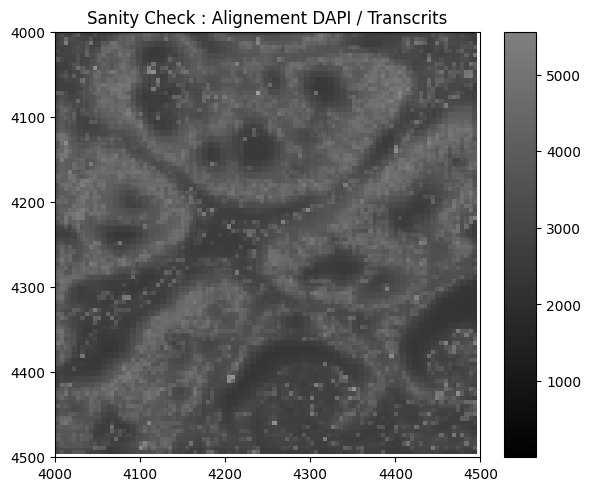

In [ ]:
import spatialdata_plot
import matplotlib.pyplot as plt

crop = spatialdata.read_zarr("/home/lilian/CRCL/xenium_training/sopa_test_crop.zarr")

# 2. Rendu Statique
print("Génération de la vignette de contrôle...")
(
    crop.pl.render_images("morphology_focus", channel=0, palette="gray") # Canal 0 = DAPI
    .pl.render_points("transcripts", alpha=0.5, size=1.0) # Transcrits en couleur
    .pl.show(title="Sanity Check : Alignement DAPI / Transcrits")
)